# ```Rollback, Maintenance, and Safe Operations```

# Rollback, Runbooks, Index Maintenance & Auditability

> 💡 **Core principle:** A production RAG system isn't just able to publish changes. It must be able to **reverse them quickly**, **validate** the result, **maintain** the index, and **prove what happened**.

---

## 1. Rollback Starts in the Architecture

First, understand why rollback is necessary for RAG.

A vector index depends on a lot of things:

```
Source data
    ↓
Chunking
    ↓
Embedding model
    ↓
Metadata enrichment
    ↓
Delete propagation
    ↓
Vector index
    ↓
Serving layer
```

**A failure can happen anywhere.** For example:

### Partial refresh

```
Partition A → updated
Partition B → updated
Partition C → STALE
```

### Embedding change

I change the embedding model and retrieval quality drops.

### Metadata bug

I accidentally break:

```
tenant_id
region
access policy
```

and users start seeing incorrect results.

### Delete failure

A document was deleted from the source, but its chunks are **still retrievable**.

> 📌 The chapter specifically lists these as common **subtle vector-platform failures**.

---

## 2. Why Rollback Is Different in RAG

In a normal application, I might say:

> "Deploy version 1.4 → bad → deploy version 1.3."

Simple.

But a retrieval system has **data state + model state + index state**.

I might need to restore:

- Index snapshot
- Alias target
- Source checkpoint
- Metadata version
- Validation evidence

> 💡 That's what the chapter calls the **known-good state**.

So "rollback" isn't just:

```
git checkout old-version
```

It can mean:

```
Bad index
   ↓
Which index was previously trusted?
   ↓
Which source checkpoint was valid?
   ↓
Which metadata version was valid?
   ↓
Did that state pass validation?
```

---

## 3. The Best Mental Model: Rollback = Circuit Breaker

The chapter gives a very good mental model:

> 💡 **Rollback is the circuit breaker of retrieval operations.**

Meaning:

```
Something is going wrong
        ↓
STOP serving bad state
        ↓
Return to known-good state
        ↓
Buy time to investigate
```

I'm not necessarily fixing the underlying problem immediately.

> 📌 I'm first **stopping the damage**.

---

## 4. Different Rollback Patterns

Not every failure requires the same rollback. The chapter gives **five patterns**:

| Pattern | Idea |
|---|---|
| A. Snapshot restore | Restore a saved index snapshot |
| B. Alias / pointer switchback | Point the serving alias back to the previous index |
| C. Checkpoint replay | Replay CDC events from a durable checkpoint |
| D. Disable the new version | Stop using the harmful version |
| E. Metadata restoration | Restore only the broken metadata from the authoritative source |

### A. Snapshot Restore

I have a snapshot:

```
index_v41
index_v42 ← current broken
```

Restore:

```
index_v41
```

Useful when my vector platform supports reliable snapshots.

| Advantage | Problem |
|---|---|
| Known, reproducible state. | Large indexes can take time to restore. |

---

## 5. B. Alias / Pointer Switchback

This is one of the **most useful** patterns.

Imagine:

```
kb-prod
   ↓
kb_v44
```

I build:

```
kb_v45
```

Then switch:

```
kb-prod
   ↓
kb_v45
```

But v45 is bad. Instead of rebuilding everything, simply switch:

```
kb-prod
   ↓
kb_v44
```

That's an **alias switchback**.

The serving layer doesn't need to know the internal index changed.

> 📌 The chapter identifies this as particularly useful for **blue-green/shadow index publication**.

---

## 6. C. Checkpoint Replay

This connects directly to the CDC we just discussed.

Suppose:

```
CDC events:
E1
E2
E3
E4
E5
```

My index successfully processed:

```
E1
E2
E3
```

but then something broke. I can replay:

```
E4
E5
```

from the **durable checkpoint**.

This helps restore source/index alignment. But it depends on:

- durable checkpoints
- correct ordering
- idempotent processing

The chapter explicitly describes checkpoint replay this way.

---

## 7. D. Disable the New Version

Sometimes the simplest response is:

```
New version is clearly harmful
        ↓
STOP using it
```

This is **fast containment**. But remember:

> ⚠️ **Disabling something isn't the same as repairing it.**

I still need to investigate the root cause later.

---

## 8. E. Metadata Restoration

Suppose:

```
Vectors = correct
Metadata = broken
```

For example:

```
tenant_id
region
security label
```

was incorrectly transformed.

I don't necessarily need to regenerate millions of embeddings. I can restore the metadata from the **authoritative source**.

That's a **targeted rollback**.

> 📌 The chapter explicitly highlights this as a case where a **full index rebuild would be unnecessary**.

---

## 9. In Practice, You Combine Them

A real incident might look like:

```
Bad refresh detected
        ↓
Pause ingestion
        ↓
Freeze cutover
        ↓
Switch alias → previous index
        ↓
Service restored
        ↓
Investigate
        ↓
Replay missed CDC events / repair metadata
        ↓
Build new version
        ↓
Validate
        ↓
Cut over again
```

> 💡 The chapter explicitly recommends: **contain first, restore service, then repair correctness.**

---

## 10. Why Shadow/Blue-Green Indexes Are Powerful

This connects to the previous chapter.

Instead of modifying production directly:

```
Production Index
     ↑
     │
     └── users
```

I build separately:

```
                    ┌──→ Production Index
                    │
Source → Pipeline ──┤
                    │
                    └──→ New Index
```

Then:

```
New Index
   ↓
Validation
   ↓
PASS
   ↓
Alias → New Index
```

If it fails:

```
Alias → Old Index
```

This is much safer than modifying the live index in place.

> 📌 The chapter explicitly says **shadow builds plus explicit cutover are easier to reverse**.

---

## 11. Three Questions for Any Rollback Strategy

This is a useful framework from the chapter:

### 1. How fast can it stop bad results?

| Action | Time |
|---|---|
| Alias switch | **seconds** |
| Rebuild entire index | hours |

### 2. How precisely does it target the broken layer?

If only metadata is wrong, don't rebuild embeddings unnecessarily.

### 3. What evidence proves the restored state is valid?

Because:

```
rollback completed
```

doesn't necessarily mean:

```
rollback successful
```

The chapter explicitly emphasizes these three questions.

---

## 12. Runbooks

Now we get to runbooks.

> 💡 A **runbook** is basically: a predefined procedure an operator follows during an incident.

Not:

> "Investigate the issue."

That's useless at 2 AM. Instead:

1. Pause refresh.
2. Freeze cutover.
3. Switch alias.
4. Run validation queries.
5. Check delete propagation.
6. Check tenant filters.
7. Notify stakeholders.

> 📌 The chapter says a usable runbook needs: **triggers, owners, containment, diagnosis, rollback, validation, communication, and follow-up.**

---

## 13. What Triggers a Rollback?

Examples:

- Recall drops
- Latency increases
- Missing records
- Delete propagation breach
- Filter mismatch
- Validation failure

So I could have:

```
IF tenant-filter validation fails
        ↓
ROLLBACK
```

or:

```
IF recall@10 < threshold
        ↓
HOLD CUTOVER
```

> ⚠️ The important thing is that the trigger should be **objective**, not: "Search feels weird."

---

## 14. Immediate Containment

When something goes wrong, first prevent more damage. Possible actions:

- Pause refresh
- Block writes
- Freeze cutover
- Isolate affected namespace

The chapter explicitly lists these containment actions.

Think:

> 💡 **Stop the bleeding before diagnosing the wound.**

---

## 15. Validation After Rollback

This is **extremely important**.

Suppose I successfully switch:

```
kb_v45 → kb_v44
```

I can't just say:

> "Done."

I need to check:

```
Document counts
        ↓
Filters
        ↓
Deletes
        ↓
Sample retrievals
        ↓
Latency
```

The chapter gives these as post-rollback validation checks.

---

## 16. The "Observable Confirmation" Rule

This is a really good operational principle:

> 💡 **If a step has no observable confirmation, it isn't done.**

For example:

| ❌ Bad | ✅ Good |
|---|---|
| "Switch the index." | Switch alias → Confirm alias points to `kb_v44` → Run validation query → Confirm expected result |

```
Switch alias
      ↓
Confirm alias points to kb_v44
      ↓
Run validation query
      ↓
Confirm expected result
```

> 📌 Every important action should **leave evidence**.

---

## 17. Index Maintenance

Now the chapter shifts from **incident response** to **preventing incidents**.

Vector indexes don't stay healthy forever. The chapter lists:

### Compaction

Especially after lots of:

```
soft deletes / tombstones
```

I can end up with dead data occupying space. So periodically:

```
tombstones
    ↓
compaction
    ↓
cleaner index
```

### Scheduled rebuilds

Useful when the index structure becomes fragmented or when I'm performing major migrations.

### Health checks

Monitor things like:

- index size
- ingestion lag
- memory pressure
- p95/p99 latency

### Metadata cleanup

Remove deprecated/inconsistent metadata fields.

### Stale partition cleanup

Old collections/namespaces shouldn't live forever.

### Model-version tracking

I should know:

> "Which embedding model generated this index?"

This becomes critical when I later migrate models.

These maintenance tasks are directly listed in the chapter.

---

## 18. Tombstones Connect Here

Remember my previous question?

> 💡 **Tombstone** = marker saying a record has been deleted.

Suppose:

| | Vectors |
|---|---|
| Total | 1,000,000 |
| Deleted over time | 100,000 |

but those records are still physically present as tombstones/soft-deleted state. Eventually:

```
tombstones accumulate
        ↓
storage increases
        ↓
index becomes less efficient
        ↓
compaction
```

That's why the chapter specifically lists **compaction after soft deletes or tombstones** as maintenance.

---

## 19. Maintenance Should Have a Rhythm

The chapter suggests thinking in different cadences.

| Cadence | Check |
|---|---|
| **Daily** | ingestion lag<br>failed validations |
| **Weekly** | delete backlog<br>storage anomalies<br>namespace drift |
| **Release-based** | embedding model changes<br>schema changes<br>chunking changes |

And potentially schedule **rebuild windows** where appropriate.

---

## 20. Auditability

Now the final major concept.

Imagine my team says:

> "We rolled back the index."

Six months later, someone asks:

- Which version?
- Why?
- Who did it?
- What was broken?
- Did validation pass?
- Were deleted documents actually gone?

If I don't have logs, **I'm guessing**.

The chapter says I should retain:

- who performed rollback
- what changed
- which versions were involved
- what validation was performed
- validation outcomes
- communication

---

## 21. Rollback Evidence

A good rollback record could say:

```
Incident: IR-4821

Bad version:
kb_v45

Rollback target:
kb_v44

Reason:
metadata_filter_mismatch

Authorized by:
oncall-platform

Validation:
✓ document count
✓ tenant filters
✓ delete sample
✓ latency
```

The chapter's example follows this exact style of recording the **incident, rollback target, trigger, authorization, and post-checks**.

---

## 22. Why My Security Architecture Cares About This

This is where I connect the entire course together.

My secure RAG system could have:

```
Source
  ↓
CDC
  ↓
Refresh pipeline
  ↓
Vector DB
  ↓
Retrieval
  ↓
Security/policy validation
  ↓
LLM
```

Now imagine a bad metadata deployment accidentally changes:

```
tenant_id
```

or:

```
access_group
```

Then retrieval could start **crossing security boundaries**.

My architecture needs the ability to:

```
Detect filter failure
       ↓
Freeze deployment
       ↓
Rollback index
       ↓
Validate tenant isolation
       ↓
Resume traffic
```

And my audit system should prove:

- Which version was active?
- Which policy metadata was used?
- What changed?
- Who rolled it back?
- Did deleted/restricted records remain inaccessible?

> 📌 That's exactly where rollback + maintenance + auditability become **security engineering** rather than just DevOps.

---

## 23. 🔴 What I MUST Know

For my goal, retain these:

### 1. Rollback

Return to a **known-good** index state.

### 2. Known-good state

Not just an old index. It includes:

- index version
- source checkpoint
- metadata version
- validation evidence

### 3. Rollback patterns

Know the idea behind:

- snapshot restore
- alias switchback
- checkpoint replay
- disable new version
- metadata restoration

### 4. Runbook

```
trigger
→ containment
→ diagnosis
→ rollback
→ validation
→ communication
→ follow-up
```

### 5. Maintenance

- compaction
- rebuilds
- health checks
- metadata cleanup
- stale partition cleanup
- model-version tracking

### 6. Auditability

> 💡 Rollback isn't complete until the restored state is **validated** and the evidence is **recorded**.

---

## 🟡 Conceptual — Know the Idea, Not the Syntax

I don't need to memorize:

```
kubectl ...
curl ...
```

or exact runbook commands. Those depend on the infrastructure.

I need to understand what the commands accomplish:

```
pause
switch
validate
record
```

---

## 🟢 Don't Waste Time

Don't memorize the exact example incident ID:

```
IR-4821
```

or exact index names:

```
kb_v2026_04_10
```

They're examples.

---

## Final Mental Model

This entire chapter can be reduced to:

```
                 NEW INDEX
                    ↓
                 VALIDATE
                    ↓
              ┌─────┴─────┐
              ↓           ↓
            PASS         FAIL
              ↓           ↓
          CUTOVER      ROLLBACK
              ↓           ↓
          PRODUCTION   KNOWN-GOOD
              │           │
              └─────┬─────┘
                    ↓
                VALIDATE
                    ↓
                  AUDIT
```

And underneath that, continuously:

```
        INDEX MAINTENANCE
               ↓
     compaction / rebuilds
     health checks / cleanup
     model-version tracking
```

> 💡 **The core principle:** a production RAG system isn't just able to publish changes. It must be able to reverse them quickly, validate the result, maintain the index, and prove what happened.

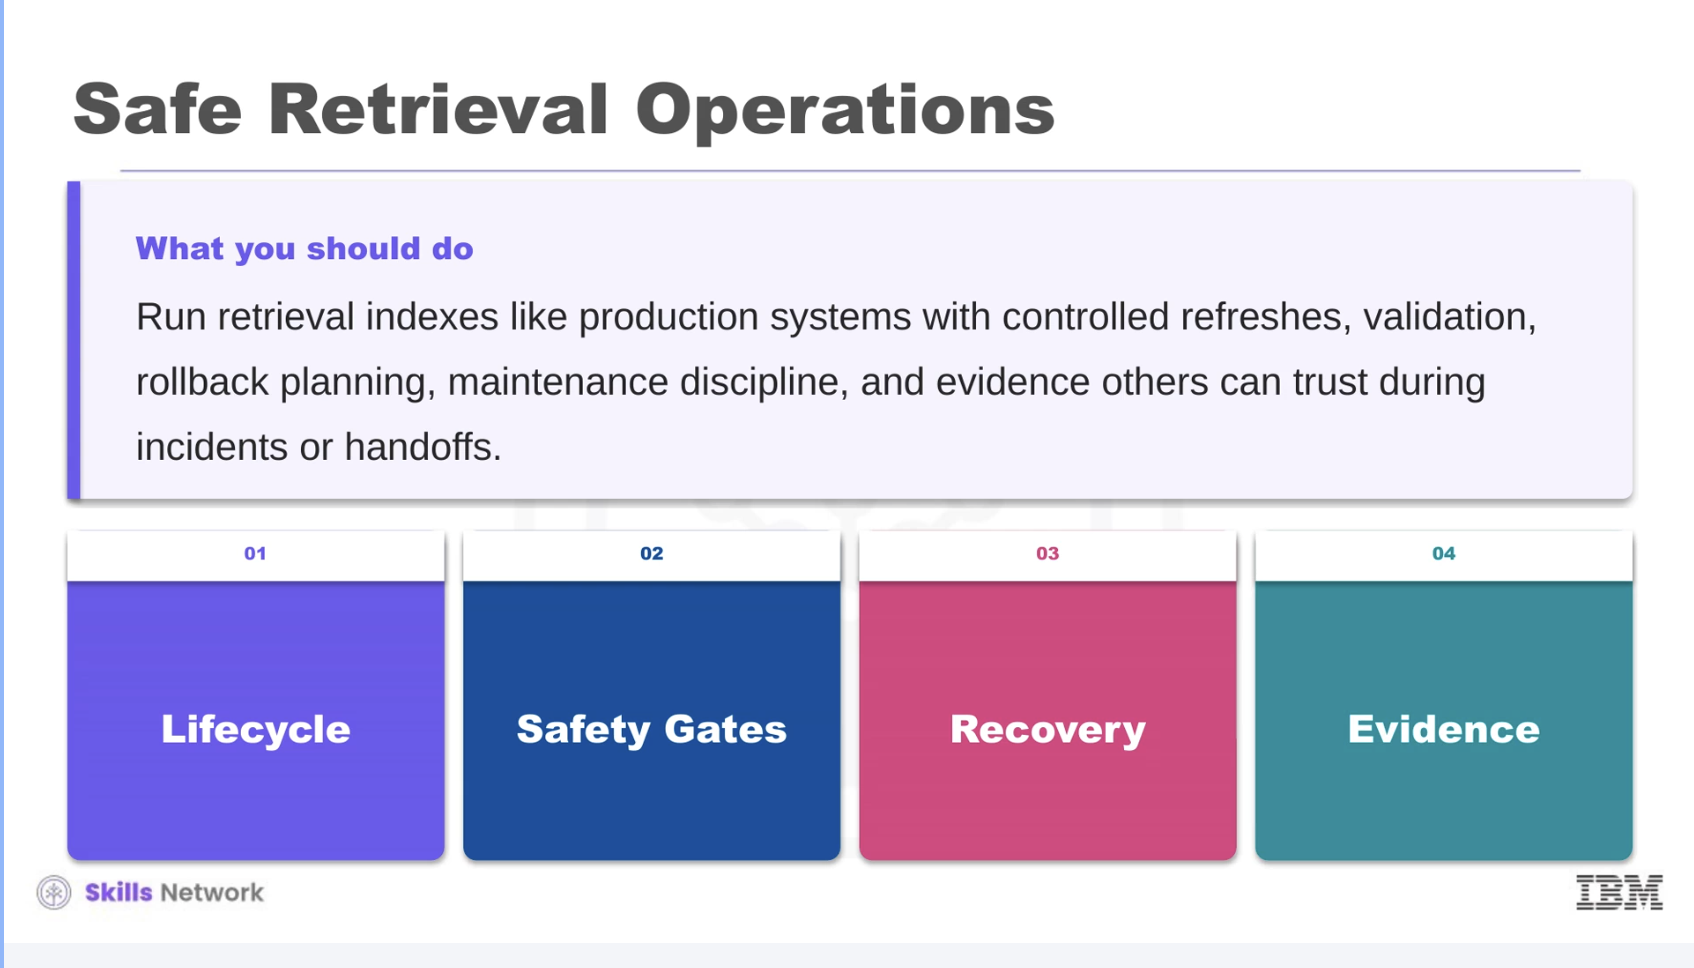

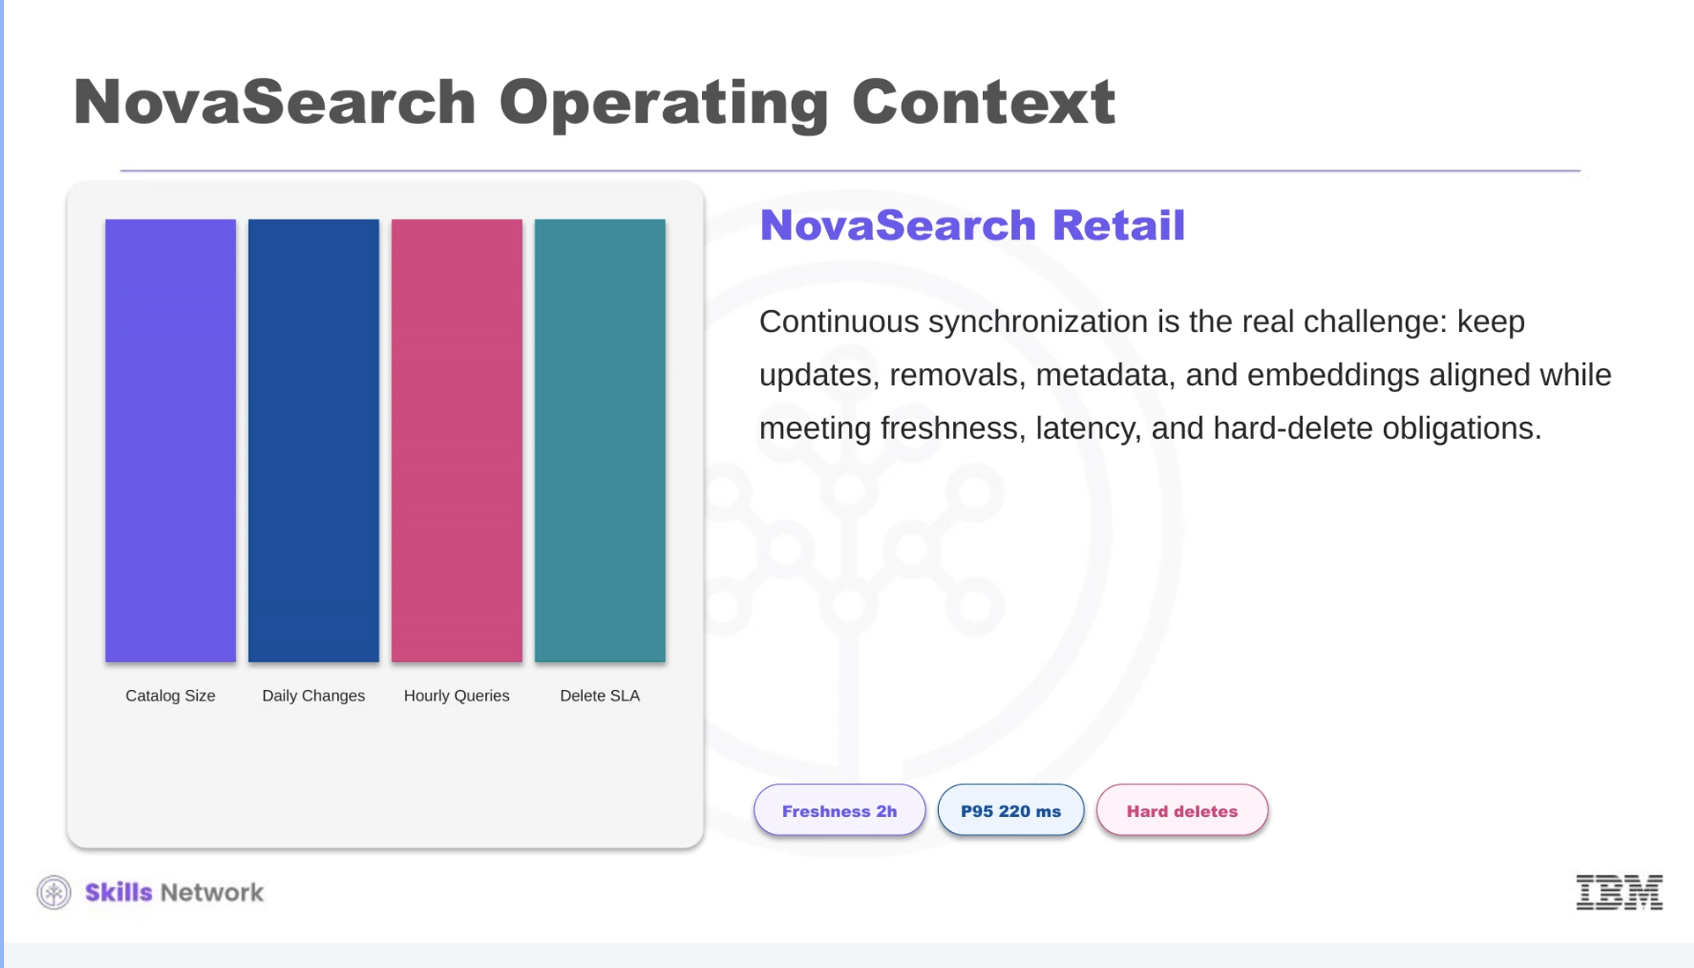

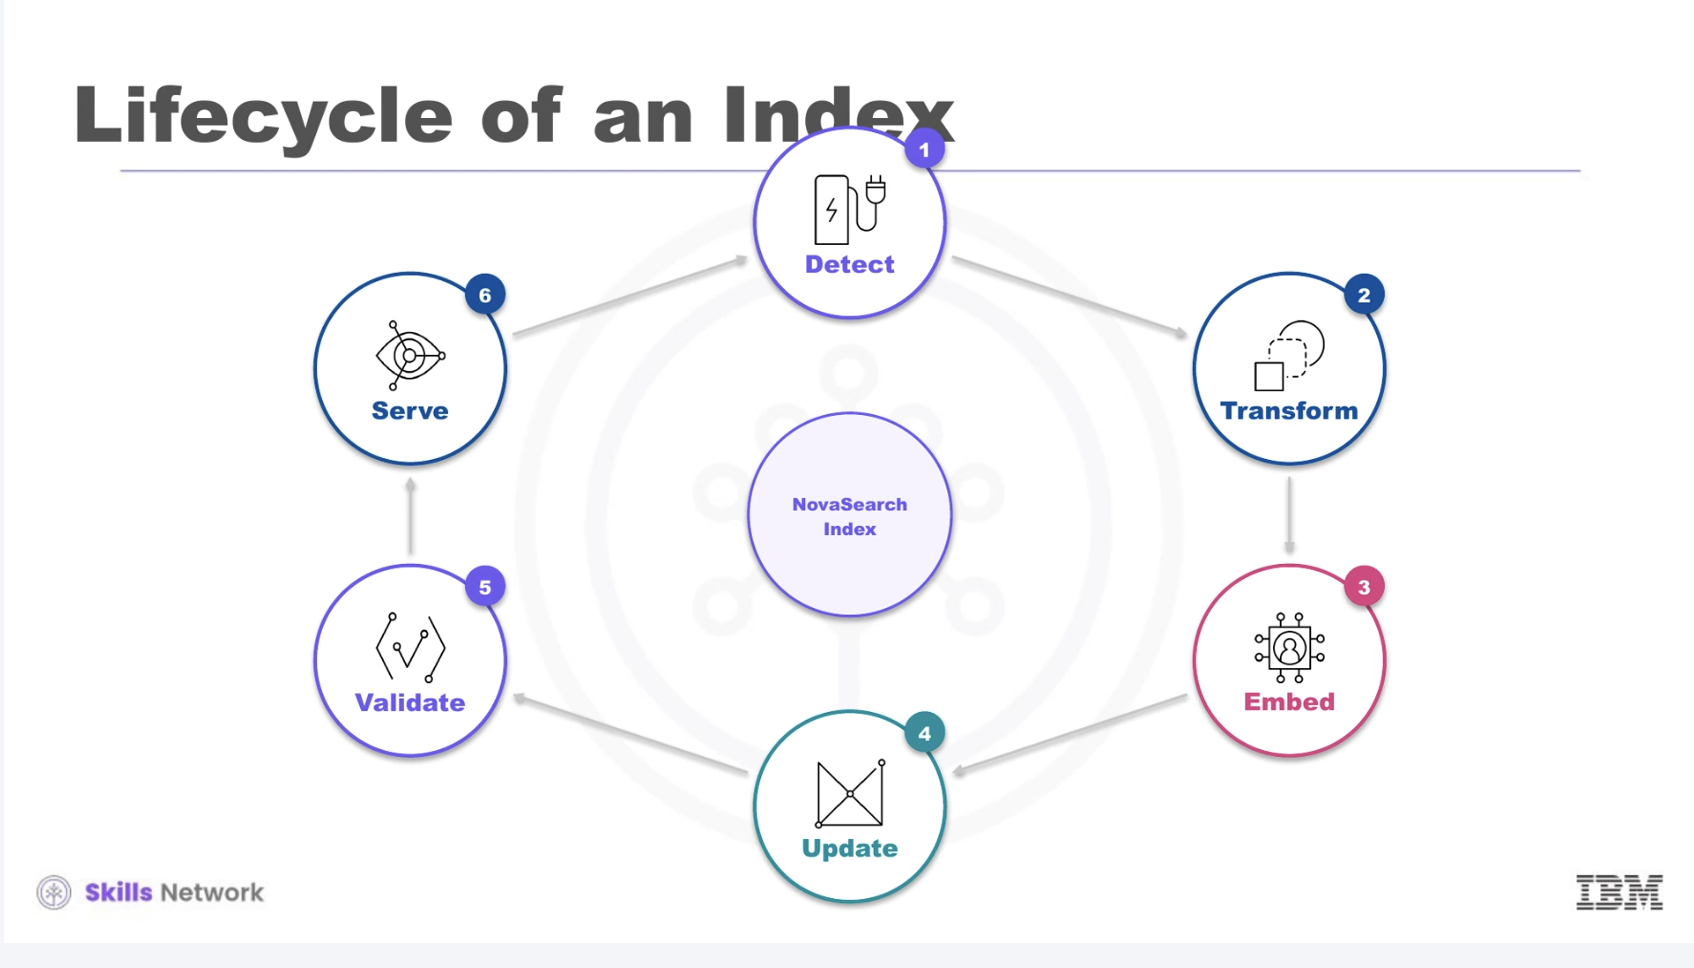
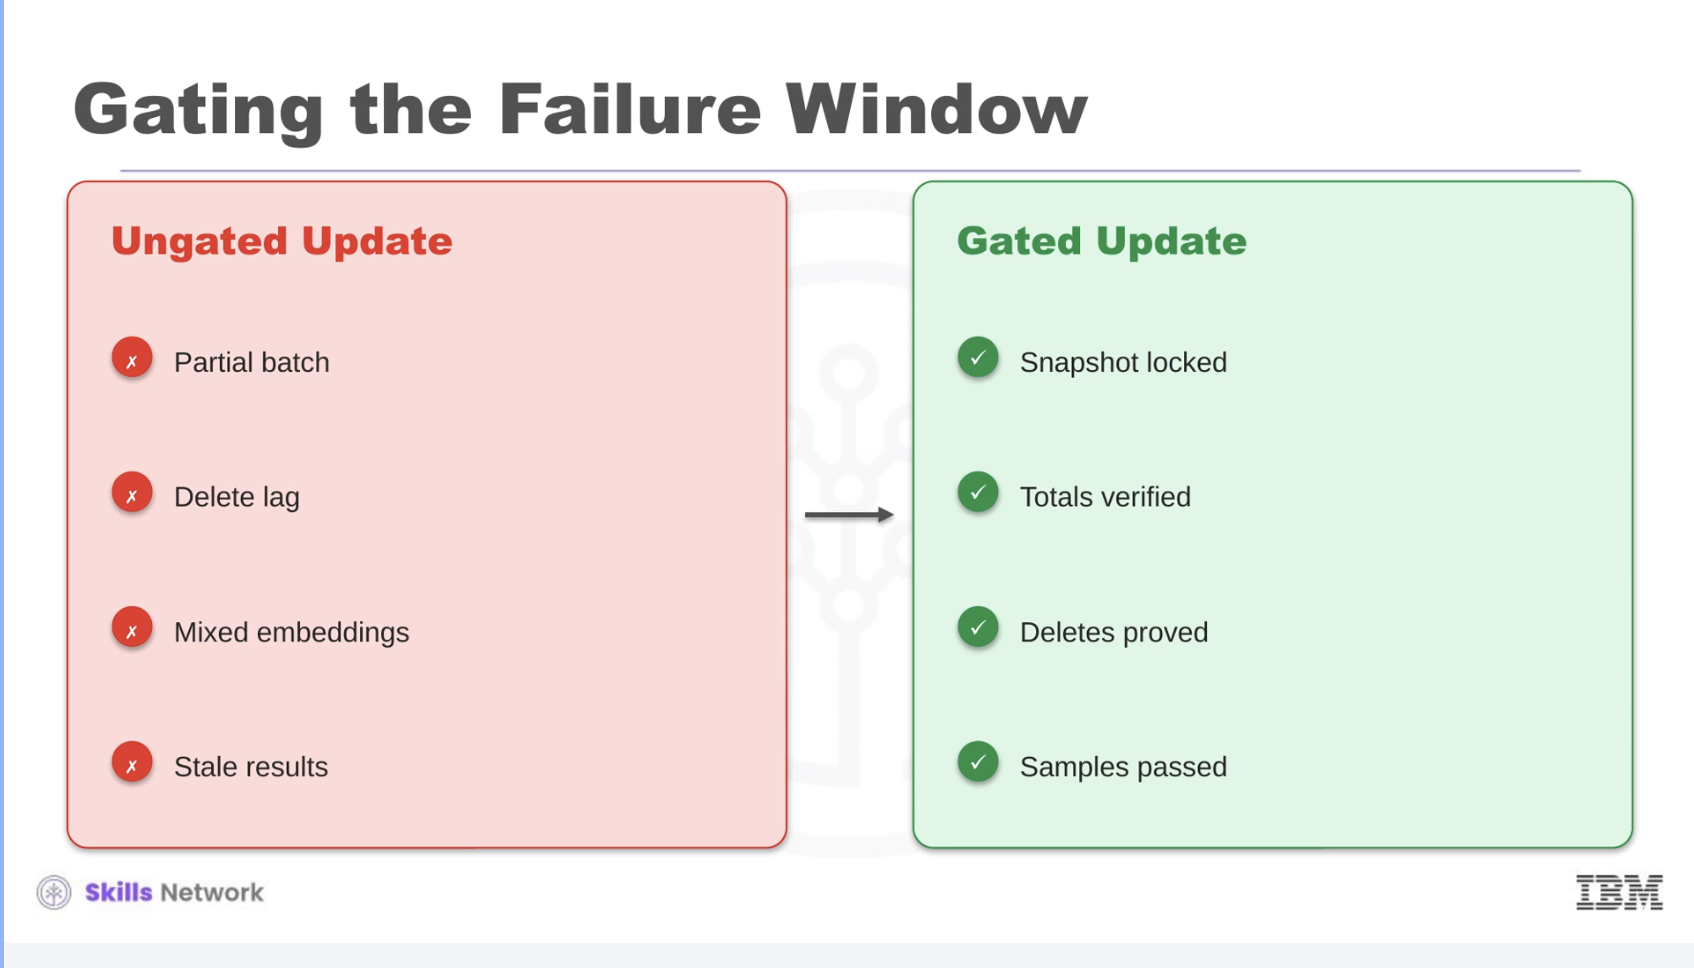
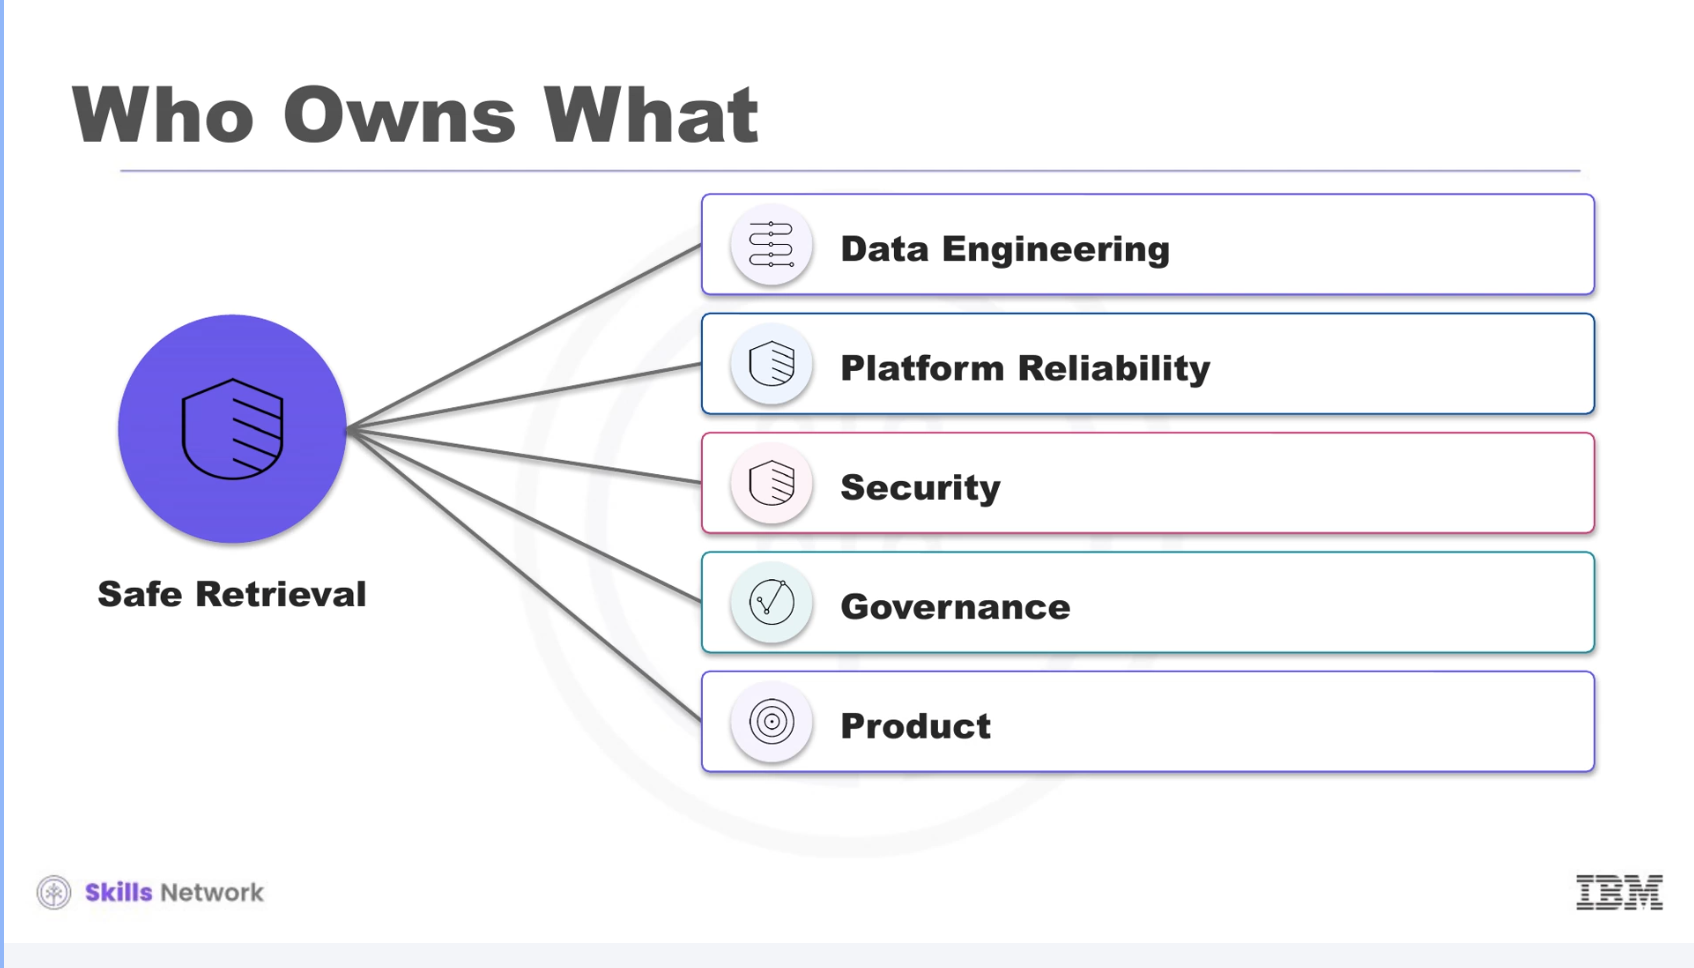
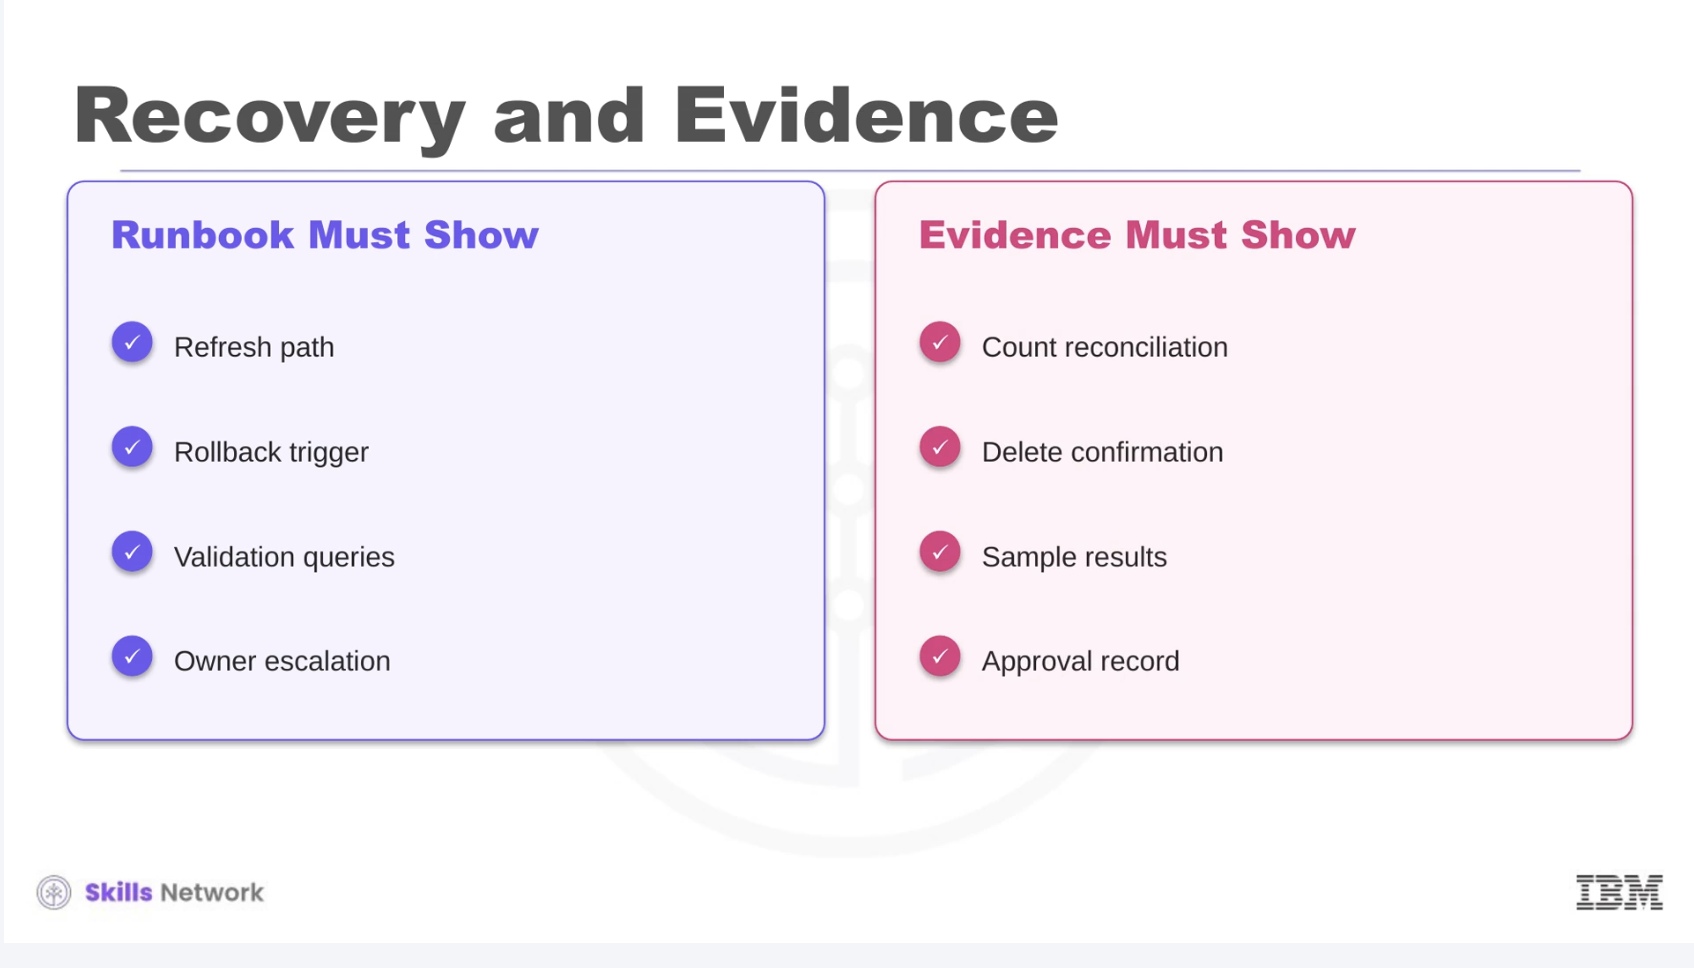